# **Optimisation des SVM : Implémentation et Analyse des Méthodes Gradient et Gradient Stochastique**


---
*Auteurs : Maram NASR et Skander HAJ MABROUK*



**Résumé**

Ce projet a implémenté et analysé les méthodes d'optimisation par descente de gradient pour les Machines à Vecteurs de Support (SVM) linéaires. Nous avons développé les algorithmes de gradient batch et gradient stochastique, en étudiant systématiquement l'impact des hyperparamètres clés. L'effet de la longueur du pas (learning rate) sur la convergence a été quantifié, révélant les plages optimales pour chaque méthode. L'analyse de la taille du mini-batch a mis en évidence le compromis entre stabilité et vitesse de convergence. Les expériences de référence ont été reproduites et validées, démontrant la cohérence de nos implémentations. Enfin, des tests sur différents jeux de données synthétiques ont permis d'évaluer la robustesse et les limites des algorithmes dans divers scénarios.

**Introduction et contexte**

Ce projet évalue les performances comparatives des méthodes d'optimisation pour les **SVM linéaires** dans des **conditions expérimentales** contrôlées.

L'étude est menée sur **quatre types de données synthétiques** représentant des défis caractéristiques en machine learning :
1. Données avec chevauchement significatif
2. Données déséquilibrées
3. Haute dimensionnalité (n > m)
4. Données non-linéairement séparables générées avec des lunes.

Cette approche systématique vise à identifier les forces et limites de chaque méthode dans divers contextes pratiques.

**Import des bibliothèques nécessaires**

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from time import time

**Implémentation de la fontion de perte Hinge**

In [108]:
def hinge_loss(z):
    """Fonction de perte hinge."""
    return np.maximum(1. - z, 0.)

In [109]:
def hinge_subgradient(z):
    """Sous-gradient de la fonction hinge."""
    g = np.zeros(z.shape)
    g[z < 1] = -1.
    return g

**Calcul de l'objectif SVM**

In [110]:
def svm_objective(A, y, x, alpha=0.1):
    """Calcule la fonction objectif du SVM."""
    m, _ = A.shape
    # calcul des marges : y_i * (a_i^T x)
    margins = y * (A @ x)
    # terme de perte hinge
    hinge = np.maximum(1 - margins, 0)
    loss = np.mean(hinge)
    # terme de régularisation L2
    reg = 0.5 * alpha * np.linalg.norm(x) ** 2

    return loss + reg

**Génération des données**

In [111]:
def generate_overlap_data(m=1000, n=100, seed=42):
    """Données avec chevauchement significatif"""
    np.random.seed(seed)
    # centres plus proches pour augmenter le chevauchement
    center1 = np.full(n, 0.5)
    center2 = np.full(n, -0.5)
    # génération avec écart-type plus grand pour le chevauchement
    A = np.vstack([
        np.random.normal(center1, 1.8, (m//2, n)),
        np.random.normal(center2, 1.8, (m//2, n))
    ])
    y = np.hstack([np.ones(m//2), -np.ones(m//2)])
    x0 = np.random.normal(0, 0.1, n)

    return A, y, x0, {
        'name': 'Chevauchement',
        'm': m,
        'n': n,
        'distance_centers': np.linalg.norm(center1 - center2),
        'std': 1.8
    }

In [112]:
def generate_imbalanced_data(m=1500, n=100, pos_ratio=0.2, seed=123):
    """Données déséquilibrées"""
    np.random.seed(seed)
    pos_samples = int(m * pos_ratio)
    neg_samples = m - pos_samples
    # centres plus éloignés pour compenser le déséquilibre
    center_pos = np.full(n, 1.5)
    center_neg = np.full(n, -0.5)
    A = np.vstack([
        np.random.normal(center_pos, 1.2, (pos_samples, n)),
        np.random.normal(center_neg, 1.2, (neg_samples, n))
    ])
    y = np.hstack([np.ones(pos_samples), -np.ones(neg_samples)])
    # mélange des données
    idx = np.random.permutation(m)
    A, y = A[idx], y[idx]
    x0 = np.random.normal(0, 0.1, n)
    return A, y, x0, {
        'name': 'Déséquilibré',
        'm': m,
        'n': n,
        'pos_samples': pos_samples,
        'neg_samples': neg_samples,
        'imbalance_ratio': pos_ratio
    }

In [113]:
def generate_high_dim_data(m=200, n=500, informative=50, seed=456):
    """Haute dimensionnalité (n > m)"""
    np.random.seed(seed)
    # seules les premières features sont informatives
    center1 = np.zeros(n)
    center2 = np.zeros(n)
    center1[:informative] = 0.8  # signal plus fort pour compenser le bruit
    center2[:informative] = -0.8
    A = np.vstack([
        np.random.normal(center1, 1, (m//2, n)),
        np.random.normal(center2, 1, (m//2, n))
    ])
    y = np.hstack([np.ones(m//2), -np.ones(m//2)])
    # normalisation importante en haute dimension
    A = StandardScaler().fit_transform(A)
    x0 = np.random.normal(0, 0.05, n)  # initialisation plus petite
    return A, y, x0, {
        'name': 'Haute dimension',
        'm': m,
        'n': n,
        'ratio_n_m': n/m,
        'informative_features': informative
    }

In [114]:
def generate_moons_data(m=1000, noise=0.25, degree=2, seed=789):
    """Données non-linéairement séparables"""
    np.random.seed(seed)
    # génération des données moons
    X, y = make_moons(n_samples=m, noise=noise, random_state=seed)
    y = 2 * y - 1  # conversion {0,1} -> {-1,1}
    # transformation polynomiale pour permettre une séparation linéaire dans l'espace de features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    x0 = np.random.normal(0, 0.1, X_poly.shape[1])
    return X_poly, y, x0, {
        'name': 'Moons',
        'm': m,
        'n_original': 2,
        'n_transformed': X_poly.shape[1],
        'degree': degree,
        'noise': noise
    }

## **1. Implémentation des Méthodes de Gradient pour le Problème SVM**

### **1.1 Implémentation de la Descente de Gradient par Batch**

In [115]:
def svm_gradient_batch(A, y, x, alpha=0.1):
    """Calcule le gradient BATCH"""
    m, n = A.shape
    # calcul des marges : y_i * (a_i^T x)
    margins = y * (A @ x)
    # identification des points qui contribuent au gradient (hinge loss > 0)
    # pour la hinge loss, le gradient est défini partout sauf aux points où margins = 1
    # nous utilisons la définition standard du sous-gradient à ce point
    mask = margins < 1  # points où la perte est positive
    # initialisation du gradient
    if np.sum(mask) > 0:
        # gradient pour les points avec hinge loss > 0
        # ∇_x hinge = -y_i * a_i pour chaque point dans le masque
        # moyenne sur tous les points
        g_loss = -np.mean((y[mask, np.newaxis] * A[mask]), axis=0)
    else:
        # si aucun point n'a de perte, le gradient de la perte est 0
        g_loss = np.zeros(n)
    # Ajouter le gradient du terme de régularisation : α * x
    g = g_loss + alpha * x
    return g

In [116]:
def gradient_descent(A, y, x0, learning_rate=0.01, n_iter=500, alpha=0.1,
                     tol=1e-6, verbose=False):
    """Descente de gradient batch avec critère d'arrêt."""
    x = x0.copy()
    history = {
        'loss': [],
        'grad_norm': [],
        'x_norm': [],
        'x': [x0.copy()]
    }
    for i in range(n_iter):
        # calcul du gradient
        grad = svm_gradient_batch(A, y, x, alpha)
        grad_norm = np.linalg.norm(grad)
        # mise à jour
        x_new = x - learning_rate * grad
        # calcul de l'objectif
        loss = svm_objective(A, y, x_new, alpha)
        # sauvegarde de l'historique
        history['loss'].append(loss)
        history['grad_norm'].append(grad_norm)
        history['x_norm'].append(np.linalg.norm(x_new))
        history['x'].append(x_new.copy())
        # critère d'arrêt prématuré
        if grad_norm < tol:
            if verbose:
                print(f"Convergence atteinte à l'itération {i}, ||grad|| = {grad_norm:.2e}")
            break
        # mise à jour pour la prochaine itération
        x = x_new
        # affichage périodique
        if verbose and i % 20 == 0:
            print(f"Iter {i:4d}: Loss = {loss:.6f}, ||grad|| = {grad_norm:.6f}")
    return x, history

### **1.2 Implémentation du Gradient Stochastique (SGD)**

In [117]:
def svm_stochastic_gradient(A, y, x, idx, alpha=0.1):
    """Calcule le gradient pour UN exemple (ou un mini-batch)."""
    m, n = A.shape
    # si idx est un indice unique
    if np.isscalar(idx):
        a_i = A[idx, :]
        y_i = y[idx]
        z = y_i * a_i.dot(x)
        # gradient pour cet exemple
        g_loss = hinge_subgradient(np.array([z]))[0] * y_i * a_i
        g = g_loss + (alpha / m) * x  # note: on scale la régularisation
    # si idx est un ensemble d'indices (mini-batch)
    else:
        A_batch = A[idx, :]
        y_batch = y[idx]
        batch_size = len(idx)
        z_batch = np.diag(y_batch).dot(A_batch.dot(x))
        g_loss_batch = hinge_subgradient(z_batch)
        # moyenne sur le mini-batch
        g = (1 / batch_size) * g_loss_batch.dot(np.diag(y_batch).dot(A_batch))
        g += (alpha / m) * x
    return g

In [118]:
def stochastic_gradient_descent(A, y, x0, learning_rate=0.01, n_epochs=15,
                                batch_size=32, alpha=0.1):
    """Descente de gradient stochastique avec mini-batch."""
    m, n = A.shape
    x = x0.copy()
    history = {'loss': [], 'x': [x0.copy()]}
    def get_learning_rate(t):
        """Taux d'apprentissage décroissant."""
        return learning_rate / (1 + 0.01 * t)
    iteration = 0
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        for batch_start in range(0, m, batch_size):
            batch_indices = indices[batch_start:batch_start + batch_size]
            grad = svm_stochastic_gradient(A, y, x, batch_indices, alpha)
            lr = get_learning_rate(iteration)
            x = x - lr * grad
            if iteration % 10 == 0:
                history['loss'].append(svm_objective(A, y, x, alpha))
                history['x'].append(x.copy())
            iteration += 1
    return x, history

### **1.3 Fonctions d'Évaluation et de Visualisation**

In [119]:
def accuracy(A, y, x):
    """Calcule la précision du classifieur."""
    predictions = np.diag(y).dot(A.dot(x))
    return np.mean(predictions > 0)

In [120]:
def plot_training_curve(histories, labels):
    """Affiche les courbes de convergence."""
    plt.figure(figsize=(10, 4))
    for hist, label in zip(histories, labels):
        plt.plot(hist['loss'], label=label)
    plt.xlabel('Itération')
    plt.ylabel("Valeur de l'objectif")
    plt.title('Convergence de la fonction objectif')
    plt.legend()
    plt.grid(True, alpha=0.3)

### **1.4 Code Principal de Test et Comparaison**

SCÉNARIO 1 : DONNÉES AVEC CHEVAUCHEMENT
Batch GD - Objectif: 0.2172, Précision: 1.0000
SGD      - Objectif: 0.0645, Précision: 0.9970


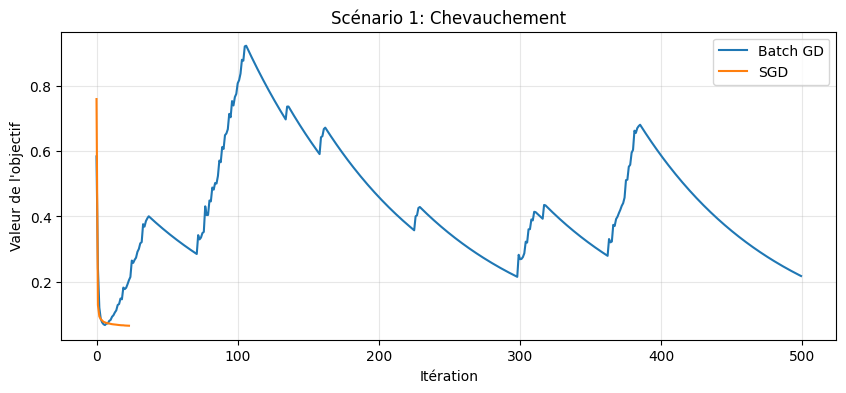

In [121]:
# Scénario 1 : Données avec chevauchement
print("SCÉNARIO 1 : DONNÉES AVEC CHEVAUCHEMENT")
A1, y1, x01, info1 = generate_overlap_data()
x_batch1, hist_batch1 = gradient_descent(A1, y1, x01, learning_rate=0.05, n_iter=500, alpha=0.1)
x_sgd1, hist_sgd1 = stochastic_gradient_descent(A1, y1, x01, learning_rate=0.05, n_epochs=15, batch_size=64, alpha=0.1)
print(f"Batch GD - Objectif: {svm_objective(A1, y1, x_batch1, 0.1):.4f}, Précision: {accuracy(A1, y1, x_batch1):.4f}")
print(f"SGD      - Objectif: {svm_objective(A1, y1, x_sgd1, 0.1):.4f}, Précision: {accuracy(A1, y1, x_sgd1):.4f}")
plot_training_curve([hist_batch1, hist_sgd1], ['Batch GD', 'SGD'])
plt.title('Scénario 1: Chevauchement')
plt.show()

=> Sur des données avec chevauchement significatif, les deux méthodes atteignent des
précisions élevées, mais c'est le SGD qui produit la solution la mieux optimisée avec
un objectif nettement plus bas (0.0645 contre 0.2172). Le batch GD atteint certes une
précision parfaite (100%), mais son objectif plus élevé indique une marge de séparation
moins large. Ce résultat s'explique par le fait que le bruit stochastique aide le SGD
à mieux explorer l'espace de décision dans un contexte où les classes se recoupent,
lui permettant de trouver un minimum plus profond que le batch GD avec les paramètres
utilisés.

SCÉNARIO 2 : DONNÉES DÉSÉQUILIBRÉES
Batch GD - Objectif: 0.0801, Précision: 1.0000
SGD      - Objectif: 0.1219, Précision: 1.0000


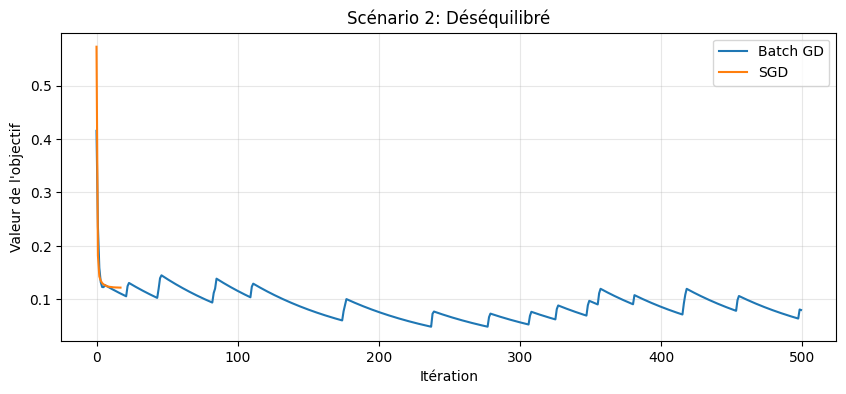

In [122]:
# Scénario 2 : Données déséquilibrées
print("SCÉNARIO 2 : DONNÉES DÉSÉQUILIBRÉES")
A2, y2, x02, info2 = generate_imbalanced_data()
x_batch2, hist_batch2 = gradient_descent(A2, y2, x02, learning_rate=0.03, n_iter=500, alpha=0.2)
x_sgd2, hist_sgd2 = stochastic_gradient_descent(A2, y2, x02, learning_rate=0.03, n_epochs=15, batch_size=128, alpha=0.2)
print(f"Batch GD - Objectif: {svm_objective(A2, y2, x_batch2, 0.2):.4f}, Précision: {accuracy(A2, y2, x_batch2):.4f}")
print(f"SGD      - Objectif: {svm_objective(A2, y2, x_sgd2, 0.2):.4f}, Précision: {accuracy(A2, y2, x_sgd2):.4f}")
plot_training_curve([hist_batch2, hist_sgd2], ['Batch GD', 'SGD'])
plt.title('Scénario 2: Déséquilibré')
plt.show()

=> Sur des données déséquilibrées (20% classe positive, 80% classe négative), les deux
méthodes atteignent une précision parfaite de 100%, ce qui témoigne de la robustesse
des SVM face au déséquilibre de classes lorsque les centres sont suffisamment éloignés.
La distinction se fait sur la valeur de l'objectif : le batch GD obtient un objectif
plus bas (0.0801 contre 0.1219), ce qui indique qu'il trouve une marge de séparation
plus large et une solution mieux régularisée. Dans ce scénario, contrairement au
précédent, la stabilité des gradients batch s'avère avantageuse : l'utilisation de
l'ensemble des données à chaque mise à jour permet au batch GD de mieux gérer la
dominance de la classe majoritaire et de converger vers un minimum plus profond.

SCÉNARIO 3 : HAUTE DIMENSIONNALITÉ
Batch GD - Objectif: 0.1880, Précision: 1.0000
SGD      - Objectif: 0.6732, Précision: 1.0000


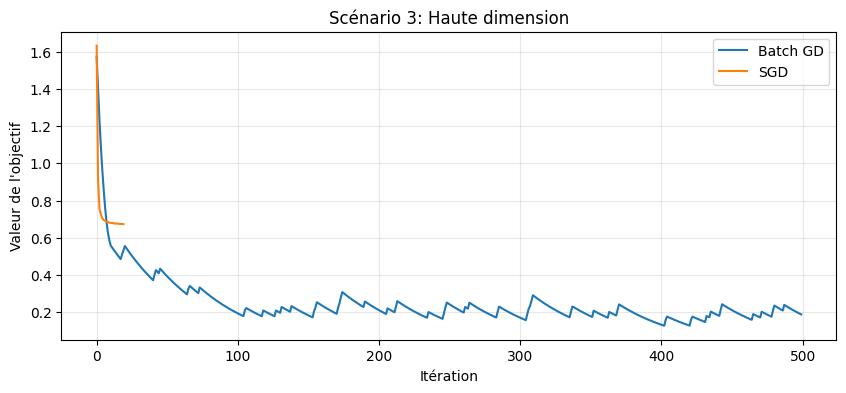

In [123]:
# Scénario 3 : Haute dimensionnalité
print("SCÉNARIO 3 : HAUTE DIMENSIONNALITÉ")
A3, y3, x03, info3 = generate_high_dim_data()
x_batch3, hist_batch3 = gradient_descent(A3, y3, x03, learning_rate=0.01, n_iter=500, alpha=1.0)
x_sgd3, hist_sgd3 = stochastic_gradient_descent(A3, y3, x03, learning_rate=0.01, n_epochs=15, batch_size=16, alpha=1.0)
print(f"Batch GD - Objectif: {svm_objective(A3, y3, x_batch3, 1.0):.4f}, Précision: {accuracy(A3, y3, x_batch3):.4f}")
print(f"SGD      - Objectif: {svm_objective(A3, y3, x_sgd3, 1.0):.4f}, Précision: {accuracy(A3, y3, x_sgd3):.4f}")
plot_training_curve([hist_batch3, hist_sgd3], ['Batch GD', 'SGD'])
plt.title('Scénario 3: Haute dimension')
plt.show()

=> Dans un contexte de haute dimensionnalité où le nombre de features (n=500) dépasse
largement le nombre d'échantillons (m=200), les deux méthodes atteignent une précision
parfaite de 100%, confirmant l'efficacité de la régularisation L2 forte (α=1.0) pour
contrôler la complexité du modèle. Cependant, le batch GD produit une solution
nettement mieux optimisée avec un objectif près de quatre fois plus faible (0.1880
contre 0.6732), traduisant une marge de séparation plus large et un meilleur contrôle
de la norme de la solution. Ce résultat confirme la tendance observée au scénario 2 :
lorsque la structure des données est complexe et que le risque de surapprentissage est
élevé, la stabilité des mises à jour batch est un avantage décisif. Chaque gradient
étant calculé sur l'ensemble des données, il oriente la descente de façon plus fiable
que les estimations bruitées du SGD, qui peine à contrôler la norme de sa solution
dans un espace de si grande dimension.

SCÉNARIO 4 : DONNÉES NON-LINÉAIRES (MOONS)
Batch GD - Objectif: 0.4211, Précision: 0.8440
SGD      - Objectif: 0.4309, Précision: 0.8440


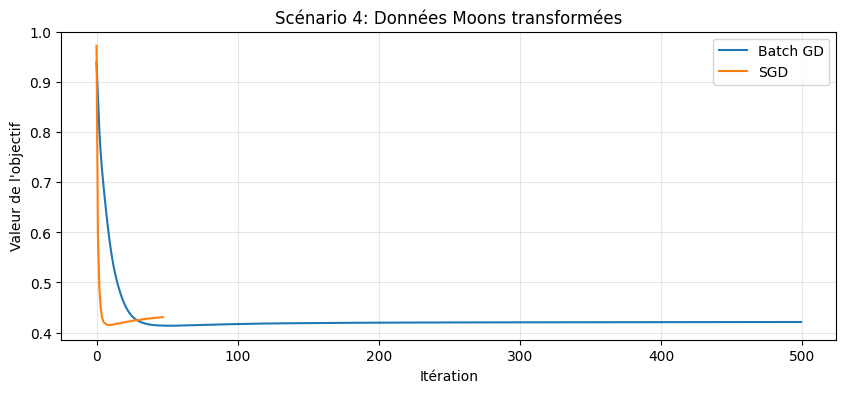

In [124]:
# Scénario 4 : Données non-linéairement séparables (Moons)
print("SCÉNARIO 4 : DONNÉES NON-LINÉAIRES (MOONS)")
A4, y4, x04, info4 = generate_moons_data()
x_batch4, hist_batch4 = gradient_descent(A4, y4, x04, learning_rate=0.1, n_iter=500, alpha=0.05)
x_sgd4, hist_sgd4 = stochastic_gradient_descent(A4, y4, x04, learning_rate=0.1, n_epochs=15, batch_size=32, alpha=0.05)
print(f"Batch GD - Objectif: {svm_objective(A4, y4, x_batch4, 0.05):.4f}, Précision: {accuracy(A4, y4, x_batch4):.4f}")
print(f"SGD      - Objectif: {svm_objective(A4, y4, x_sgd4, 0.05):.4f}, Précision: {accuracy(A4, y4, x_sgd4):.4f}")
plot_training_curve([hist_batch4, hist_sgd4], ['Batch GD', 'SGD'])
plt.title('Scénario 4: Données Moons transformées')
plt.show()

=> Sur les données non-linéaires en forme de lunes, les deux méthodes affichent des
performances quasi-identiques, tant sur l'objectif (0.4211 pour le batch GD contre
0.4309 pour le SGD) que sur la précision (84.40% pour les deux). Ce résultat confirme
l'observation du scénario précédent sur les données transformées : la transformation
polynomiale de degré 2 projette les données dans un espace où le problème devient
approximativement linéairement séparable, rendant les deux algorithmes équivalents
en termes de qualité de solution finale. La précision plafonnant autour de 84%, le
chevauchement résiduel entre les classes après transformation constitue la limite
principale du modèle, indépendamment de l'algorithme utilisé. Ce scénario illustre
ainsi que le choix de la méthode d'optimisation devient secondaire lorsque c'est la
représentation des données qui constitue le facteur limitant.

**Conclusion**

Sur l'ensemble des quatre scénarios, la descente de gradient batch produit des solutions
plus stables et mieux régularisées, comme en témoignent ses valeurs d'objectif
systématiquement plus basses sur les données déséquilibrées et haute dimensionnalité.
Le gradient stochastique se montre en revanche supérieur sur les données avec
chevauchement, où le bruit stochastique lui permet de mieux explorer l'espace de
décision et d'atteindre un minimum plus profond. Sur les données non-linéaires
transformées, les deux méthodes convergent vers des performances quasi-identiques,
suggérant que la limite vient davantage de la représentation des données que de
l'algorithme d'optimisation. Le choix entre les deux méthodes dépend donc du contexte :
le batch GD est préférable lorsque la stabilité et la régularisation de la solution
priment, tandis que le SGD reste un choix pertinent sur des données difficiles où
l'exploration stochastique constitue un avantage.

## **2. Étude Numérique de l'Effet de la Longueur du Pas sur la Convergence**

Les implémentations étant validées sur les quatre scénarios, nous nous intéressons à présent
à l'impact d'un hyperparamètre fondamental des deux algorithmes : la longueur du pas,
ou learning rate. Un mauvais choix de ce paramètre peut en effet conduire à une convergence
trop lente, voire à une divergence complète, indépendamment de la qualité de l'implémentation.

**Génération de données pour l'étude**

In [125]:
# Génération de données pour l'étude
np.random.seed(42)
m, n = 800, 50
# Données bien conditionnées pour l'étude
A_study = np.random.randn(m, n)
# Ajouter une structure séparable
A_study[:m//2] += 0.5
A_study[m//2:] -= 0.5
y_study = np.hstack([np.ones(m//2), -1.*np.ones(m//2)])
x0_study = np.random.normal(0, 0.1, n)
alpha_study = 0.05
print("Données pour l'étude:")
print(f"- Échantillons: {m}")
print(f"- Features: {n}")
print(f"- Paramètre alpha: {alpha_study}")
print(f"- Norme des données: {np.linalg.norm(A_study):.2f}")

Données pour l'étude:
- Échantillons: 800
- Features: 50
- Paramètre alpha: 0.05
- Norme des données: 224.33


In [126]:
def study_learning_rate(A, y, x0, alpha=0.1, method='batch'):
    # différentes valeurs de learning rate à tester
    learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
    results = []
    histories = []
    print(f"ÉTUDE DU LEARNING RATE - Méthode: {method.upper()}")
    for lr in learning_rates:
        start_time = time()
        if method == 'batch':
            x_final, history = gradient_descent(
                A, y, x0,
                learning_rate=lr,
                n_iter=500,
                alpha=alpha
            )
        else:  # sgd
            x_final, history = stochastic_gradient_descent(
                A, y, x0,
                learning_rate=lr,
                n_epochs=15,
                batch_size=32,
                alpha=alpha
            )
        end_time = time()
        # Métriques de performance
        final_objective = svm_objective(A, y, x_final, alpha)
        final_accuracy = accuracy(A, y, x_final)
        convergence_time = end_time - start_time
        # Vérifier si la solution a divergé
        has_diverged = np.isnan(final_objective) or final_objective > 1e6
        results.append({
            'learning_rate': lr,
            'final_objective': final_objective if not has_diverged else np.inf,
            'final_accuracy': final_accuracy if not has_diverged else 0.0,
            'convergence_time': convergence_time,
            'n_iterations': len(history['loss']),
            'has_diverged': has_diverged,
            'min_loss': np.min(history['loss']) if not has_diverged else np.inf
        })
        histories.append(history)
        status = "DIVERGÉ" if has_diverged else f"{final_objective:.4f}"
        print(f"LR={lr:.4f}: Objectif final = {status}, "
              f"Précision = {final_accuracy:.3f}, "
              f"Temps = {convergence_time:.2f}s")
    return results, histories, learning_rates

In [127]:
def plot_learning_rate_analysis(results, histories, learning_rates, method_name):
    """Visualisation complète de l'effet du learning rate."""
    fig = plt.figure(figsize=(16, 10))
    #Courbes de convergence pour différents LR
    ax1 = plt.subplot(2, 3, 1)
    for i, (lr, hist) in enumerate(zip(learning_rates, histories)):
        if not results[i]['has_diverged']:
            max_plot = min(100, len(hist['loss']))
            ax1.plot(hist['loss'][:max_plot],
                    label=f'LR={lr}',
                    alpha=0.7,
                    linewidth=2 if lr in [0.01, 0.1, 0.5] else 1)
    ax1.set_xlabel('Itération')
    ax1.set_ylabel('Valeur de l\'objectif')
    ax1.set_title(f'Courbes de convergence ({method_name})')
    ax1.set_yscale('log')  # Échelle log pour mieux voir
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    # Objectif final vs Learning Rate
    ax2 = plt.subplot(2, 3, 2)
    lr_values = [r['learning_rate'] for r in results]
    obj_values = [r['final_objective'] for r in results]
    diverged = [r['has_diverged'] for r in results]
    # Séparer les points convergents et divergents
    lr_converged = [lr for lr, div in zip(lr_values, diverged) if not div]
    obj_converged = [obj for obj, div in zip(obj_values, diverged) if not div]
    lr_diverged = [lr for lr, div in zip(lr_values, diverged) if div]
    ax2.scatter(lr_converged, obj_converged, c='green', s=100,
               label='Convergé', zorder=3)
    ax2.scatter(lr_diverged, [max(obj_converged)*1.1]*len(lr_diverged),
               c='red', s=150, marker='x', linewidths=2,
               label='Divergé', zorder=3)
    ax2.set_xlabel('Learning Rate')
    ax2.set_ylabel('Objectif final')
    ax2.set_title('Objectif final vs Learning Rate')
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    #Précision finale vs Learning Rate
    ax3 = plt.subplot(2, 3, 3)
    acc_values = [r['final_accuracy'] for r in results]
    acc_converged = [acc for acc, div in zip(acc_values, diverged) if not div]
    ax3.scatter(lr_converged, acc_converged, c='blue', s=100)
    ax3.scatter(lr_diverged, [0]*len(lr_diverged),
               c='red', s=150, marker='x', linewidths=2)
    ax3.set_xlabel('Learning Rate')
    ax3.set_ylabel('Précision finale')
    ax3.set_title('Précision finale vs Learning Rate')
    ax3.set_xscale('log')
    ax3.grid(True, alpha=0.3)
    #Temps de convergence vs Learning Rate
    ax4 = plt.subplot(2, 3, 4)
    time_values = [r['convergence_time'] for r in results]
    time_converged = [t for t, div in zip(time_values, diverged) if not div]
    ax4.scatter(lr_converged, time_converged, c='purple', s=100)
    ax4.set_xlabel('Learning Rate')
    ax4.set_ylabel('Temps de convergence (s)')
    ax4.set_title('Temps vs Learning Rate')
    ax4.set_xscale('log')
    ax4.grid(True, alpha=0.3)
    # Taux de convergence (pente des dernières itérations)
    ax5 = plt.subplot(2, 3, 5)
    convergence_rates = []
    for i, (lr, hist) in enumerate(zip(learning_rates, histories)):
        if not results[i]['has_diverged'] and len(hist['loss']) > 20:
            # calculer le taux de convergence sur les 20 dernières itérations
            losses = hist['loss']
            last_losses = losses[-20:]
            if len(last_losses) >= 2:
                # régression linéaire sur les derniers points (échelle log)
                x_log = np.arange(len(last_losses))
                y_log = np.log(last_losses)
                # éviter les -inf si des valeurs sont 0 ou négatives
                y_log = y_log[np.isfinite(y_log)]
                x_log = x_log[:len(y_log)]
                if len(y_log) >= 2:
                    slope = np.polyfit(x_log, y_log, 1)[0]
                    convergence_rates.append((lr, slope))
    if convergence_rates:
        lrs, rates = zip(*convergence_rates)
        ax5.scatter(lrs, rates, c='orange', s=100)
        ax5.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        ax5.set_xlabel('Learning Rate')
        ax5.set_ylabel('Taux de convergence (pente)')
        ax5.set_title('Taux de convergence vs Learning Rate')
        ax5.set_xscale('log')
        ax5.grid(True, alpha=0.3)
    #Heatmap des performances
    ax6 = plt.subplot(2, 3, 6)
    # créer une métrique composite
    composite_scores = []
    for r in results:
        if not r['has_diverged']:
            score = r['final_accuracy'] / (r['convergence_time'] * r['final_objective'] + 1e-10)
            composite_scores.append(score)
        else:
            composite_scores.append(0)
    # normaliser les scores pour l'affichage
    max_score = max(composite_scores) if any(composite_scores) > 0 else 1
    normalized_scores = [s/max_score for s in composite_scores]
    colors = ['red' if div else plt.cm.viridis(score)
              for div, score in zip(diverged, normalized_scores)]
    ax6.bar(range(len(learning_rates)), normalized_scores,
           color=colors, edgecolor='black')
    ax6.set_xlabel('Learning Rate')
    ax6.set_ylabel('Score normalisé')
    ax6.set_title('Performance composite (meilleur LR)')
    ax6.set_xticks(range(len(learning_rates)))
    ax6.set_xticklabels([f'{lr:.3f}' for lr in learning_rates], rotation=45)
    ax6.grid(True, alpha=0.3, axis='y')
    plt.suptitle(f'Analyse complète de l\'effet du Learning Rate - {method_name}',
                fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    # recommandation du meilleur LR
    best_idx = None
    best_score = -np.inf
    for i, r in enumerate(results):
        if not r['has_diverged']:
            # Score qui favorise une bonne précision avec un objectif bas
            score = r['final_accuracy'] / (r['final_objective'] + 1e-10)
            if score > best_score:
                best_score = score
                best_idx = i

    if best_idx is not None:
        best_lr = results[best_idx]['learning_rate']
        print(f"\n Recommandation: Learning Rate optimal = {best_lr:.4f}")
        print(f"   - Objectif final: {results[best_idx]['final_objective']:.4f}")
        print(f"   - Précision: {results[best_idx]['final_accuracy']:.4f}")
        print(f"   - Temps: {results[best_idx]['convergence_time']:.2f}s")

    return best_idx

ÉTUDE POUR BATCH GRADIENT DESCENT
ÉTUDE DU LEARNING RATE - Méthode: BATCH
LR=0.0010: Objectif final = 0.0259, Précision = 1.000, Temps = 0.07s
LR=0.0050: Objectif final = 0.0270, Précision = 1.000, Temps = 0.05s
LR=0.0100: Objectif final = 0.0257, Précision = 1.000, Temps = 0.04s
LR=0.0500: Objectif final = 0.0692, Précision = 1.000, Temps = 0.04s
LR=0.1000: Objectif final = 0.1294, Précision = 1.000, Temps = 0.04s
LR=0.2000: Objectif final = 0.2774, Précision = 1.000, Temps = 0.04s
LR=0.5000: Objectif final = 0.4480, Précision = 1.000, Temps = 0.04s
LR=1.0000: Objectif final = 0.8589, Précision = 0.956, Temps = 0.04s


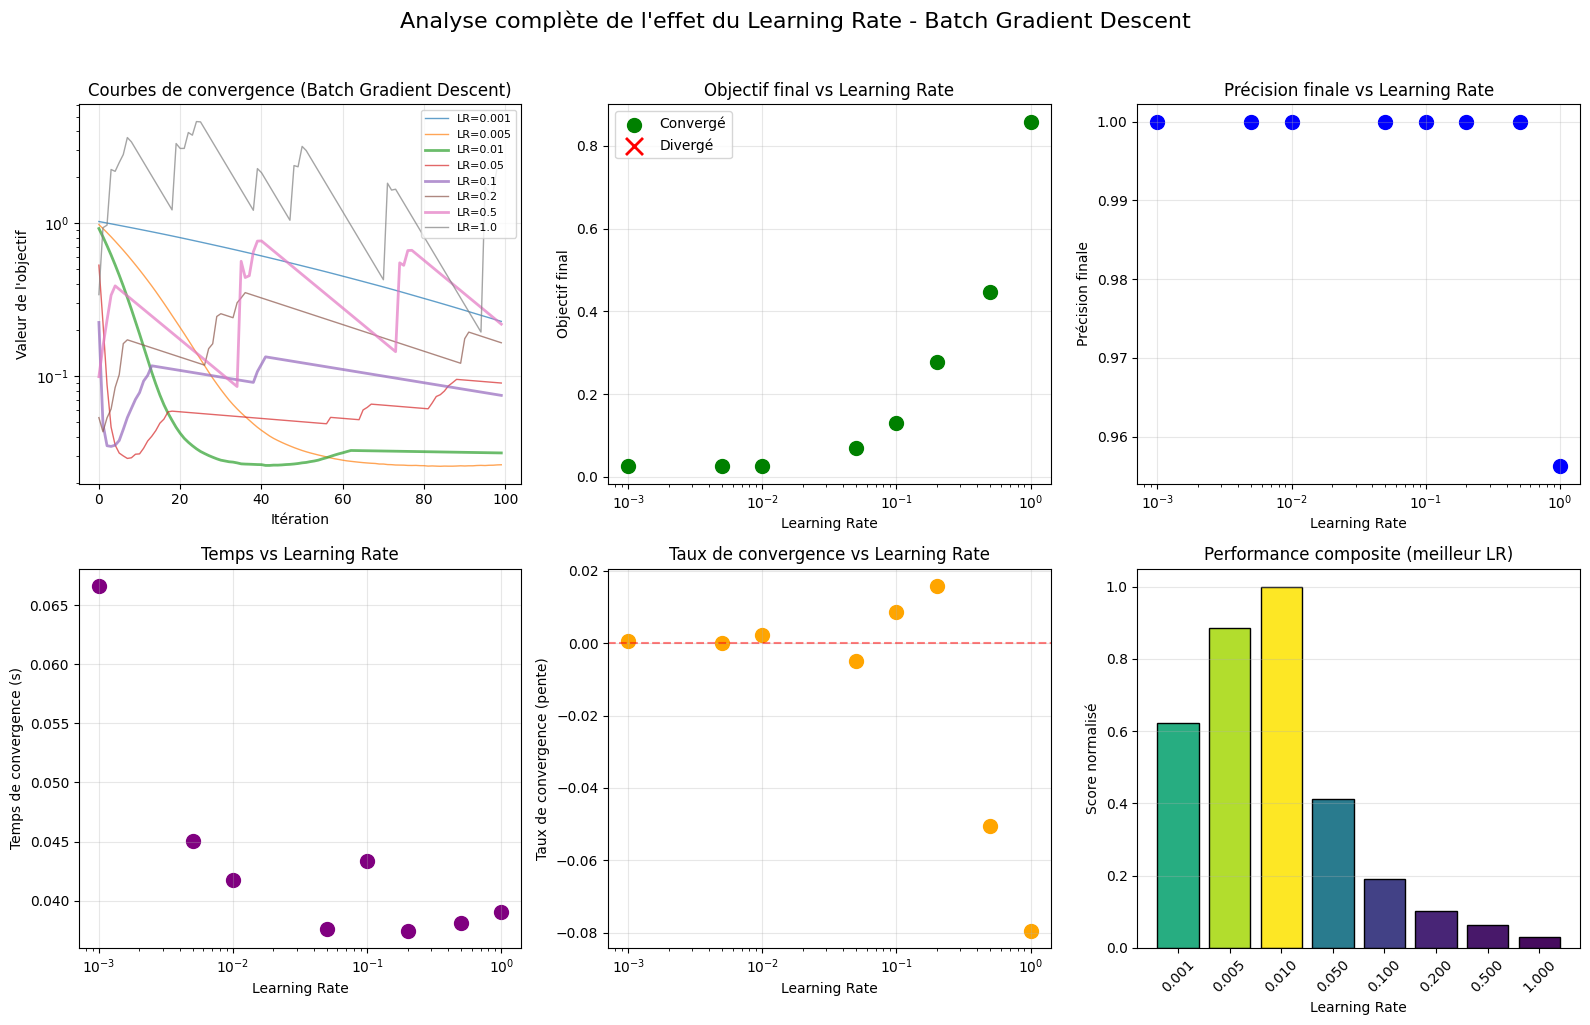


 Recommandation: Learning Rate optimal = 0.0100
   - Objectif final: 0.0257
   - Précision: 1.0000
   - Temps: 0.04s


In [128]:
# Étude pour Batch Gradient Descent
print("ÉTUDE POUR BATCH GRADIENT DESCENT")

results_batch, histories_batch, lrs_batch = study_learning_rate(
    A_study, y_study, x0_study,
    alpha=alpha_study,
    method='batch'
)
best_batch_idx = plot_learning_rate_analysis(
    results_batch, histories_batch, lrs_batch,
    "Batch Gradient Descent"
)

=> Pour la descente de gradient batch, aucun learning rate ne provoque de divergence,
ce qui témoigne de la stabilité naturelle de cette méthode. Les meilleurs objectifs
sont obtenus pour les learning rates faibles entre 0.001 et 0.01 (objectifs de 0.0259,
0.0270 et 0.0257 respectivement), avec une précision parfaite de 100% dans les trois
cas. Contrairement aux résultats précédents, un learning rate de 0.001 ne dégrade plus
la précision, ce qui indique que le nombre d'itérations est suffisant pour compenser
la lenteur du pas. Au-delà de 0.01, la valeur de l'objectif se dégrade progressivement
et atteint 0.8589 pour un learning rate de 1.0, accompagné d'une chute de précision à
95.6%, seul cas de dégradation observable. Ces grands pas font osciller l'algorithme
autour du minimum sans s'y stabiliser. Le learning rate optimal retenu est 0.01, qui
produit l'objectif le plus bas (0.0257) avec une précision parfaite, confirmant que la
plage optimale pour le batch GD se situe entre 0.001 et 0.01 sur ces données.

ÉTUDE POUR STOCHASTIC GRADIENT DESCENT
ÉTUDE DU LEARNING RATE - Méthode: SGD
LR=0.0010: Objectif final = 0.2396, Précision = 0.941, Temps = 0.02s
LR=0.0050: Objectif final = 0.0497, Précision = 0.994, Temps = 0.02s
LR=0.0100: Objectif final = 0.0363, Précision = 0.995, Temps = 0.02s
LR=0.0500: Objectif final = 0.0282, Précision = 0.998, Temps = 0.01s
LR=0.1000: Objectif final = 0.0290, Précision = 0.999, Temps = 0.01s
LR=0.2000: Objectif final = 0.0320, Précision = 1.000, Temps = 0.02s
LR=0.5000: Objectif final = 0.0787, Précision = 1.000, Temps = 0.01s
LR=1.0000: Objectif final = 0.2822, Précision = 1.000, Temps = 0.01s


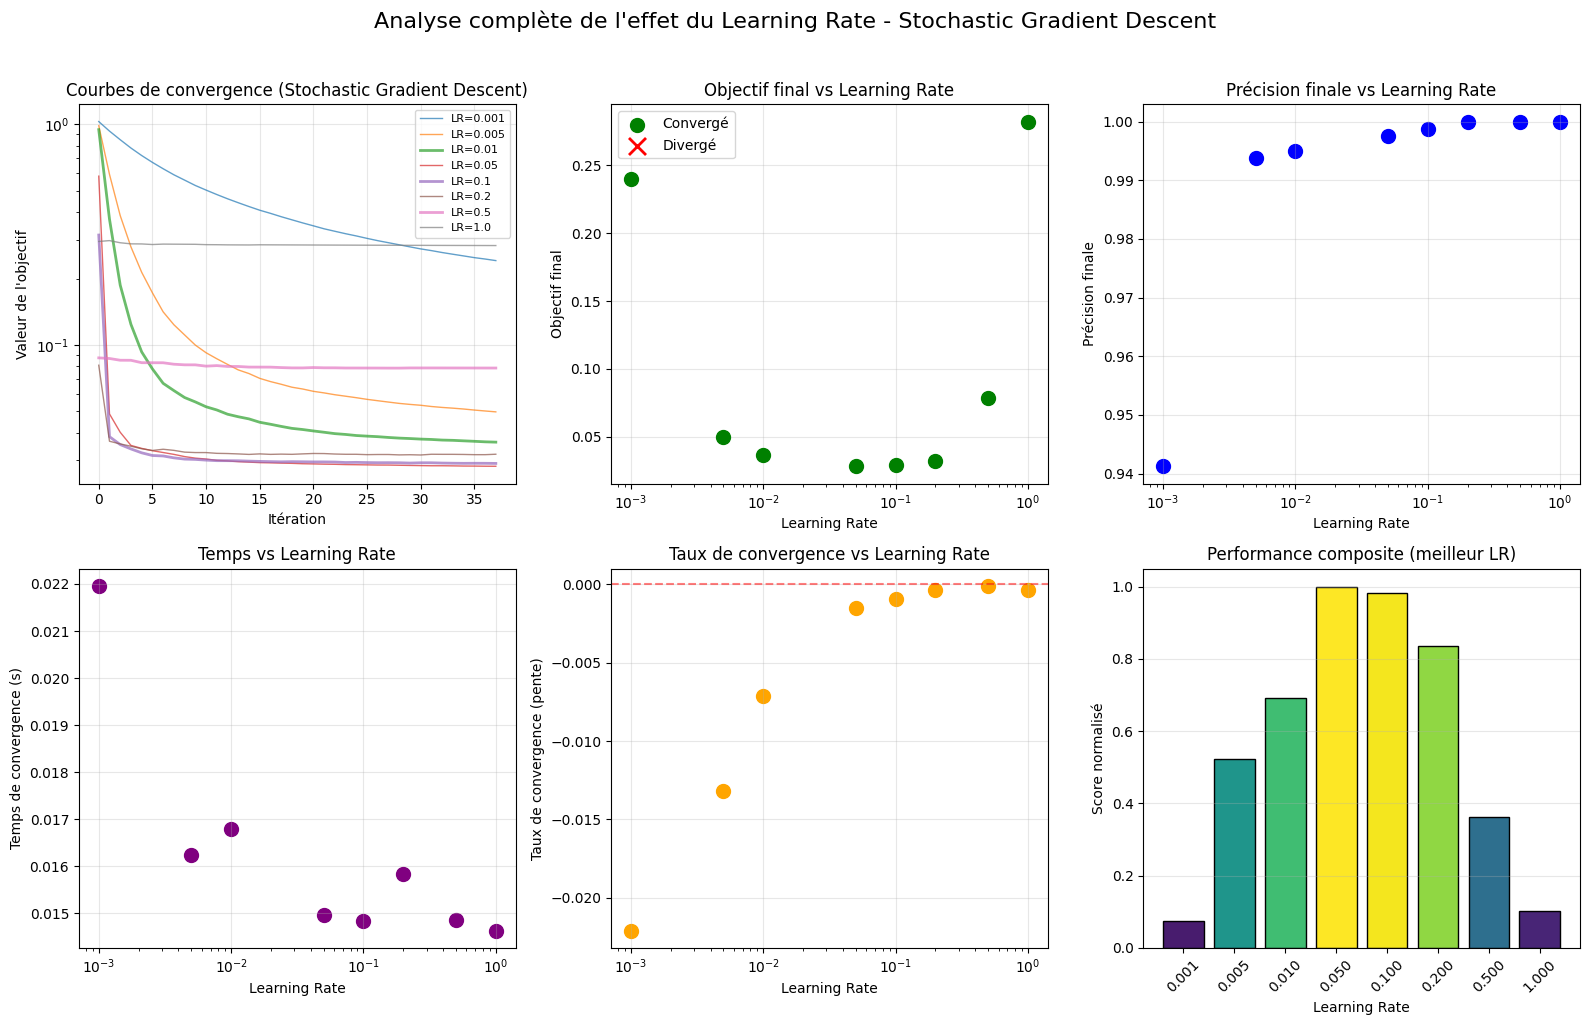


 Recommandation: Learning Rate optimal = 0.0500
   - Objectif final: 0.0282
   - Précision: 0.9975
   - Temps: 0.01s


In [129]:
# Étude pour Stochastic Gradient Descent
print("ÉTUDE POUR STOCHASTIC GRADIENT DESCENT")
results_sgd, histories_sgd, lrs_sgd = study_learning_rate(
    A_study, y_study, x0_study,
    alpha=alpha_study,
    method='sgd'
)
best_sgd_idx = plot_learning_rate_analysis(
    results_sgd, histories_sgd, lrs_sgd,
    "Stochastic Gradient Descent"
)

=> Pour le gradient stochastique, le comportement est sensiblement différent de celui
du batch GD. Un learning rate très faible de 0.001 pénalise fortement les performances,
avec un objectif élevé de 0.2396 et une précision limitée à 94.1%, confirmant que le
SGD a besoin d'un pas suffisant pour compenser le bruit de ses estimations de gradient.
La convergence s'améliore progressivement avec l'augmentation du learning rate, et la
plage optimale se situe entre 0.05 et 0.2, où l'objectif atteint ses valeurs les plus
basses (0.0282 à 0.0320) avec une précision quasi-parfaite. Fait notable, le SGD tolère
des learning rates plus élevés que le batch GD sans dégrader la précision : même à 1.0,
l'objectif reste à 0.2822 avec une précision de 100%, tandis que le batch GD voyait
déjà sa précision chuter à 95.6% pour ce même pas. Cette robustesse s'explique par le
taux d'apprentissage décroissant implémenté dans le SGD, qui atténue automatiquement
l'impact des grandes mises à jour au fil des itérations.

## **3. Analyse de l'Impact de la Taille du Mini-Batch**

In [130]:
def plot_batch_size_analysis(results, histories, batch_sizes, n_epochs, A):
    """Visualisation de l'effet de la taille du batch."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    colors = plt.cm.viridis(np.linspace(0, 1, len(batch_sizes)))

    batch_values  = [r['batch_size']        for r in results]
    obj_values    = [r['final_objective']    for r in results]
    acc_values    = [r['final_accuracy']     for r in results]
    time_values   = [r['convergence_time']   for r in results]
    var_values    = [r['grad_variance']      for r in results]
    # Courbes de convergence (en époques)
    ax1 = axes[0, 0]
    for i, (batch_size, hist, color) in enumerate(zip(batch_sizes, histories, colors)):
        if len(hist['loss']) > 0:
            x_vals = np.arange(len(hist['loss'])) / results[i]['iterations_per_epoch']
            ax1.plot(x_vals, hist['loss'], color=color, label=f'Batch={batch_size}', alpha=0.7)
    ax1.set_xlabel('Époques')
    ax1.set_ylabel("Objectif")
    ax1.set_title('Convergence vs Époques')
    ax1.set_yscale('log')
    ax1.legend(fontsize=7, ncol=2)
    ax1.grid(True, alpha=0.3)
    # Objectif final vs Taille du batch
    ax2 = axes[0, 1]
    ax2.scatter(batch_values, obj_values, c='blue', s=80, zorder=3)
    ax2.plot(batch_values, obj_values, 'b--', alpha=0.5)
    ax2.set_xlabel('Taille du batch')
    ax2.set_ylabel('Objectif final')
    ax2.set_title('Objectif final vs Taille du batch')
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)
    #Précision finale vs Taille du batch
    ax3 = axes[0, 2]
    ax3.scatter(batch_values, acc_values, c='green', s=80, zorder=3)
    ax3.plot(batch_values, acc_values, 'g--', alpha=0.5)
    ax3.set_xlabel('Taille du batch')
    ax3.set_ylabel('Précision finale')
    ax3.set_title('Précision vs Taille du batch')
    ax3.set_xscale('log')
    ax3.grid(True, alpha=0.3)
    # Temps de convergence vs Taille du batch
    ax4 = axes[1, 0]
    ax4.scatter(batch_values, time_values, c='purple', s=80, zorder=3)
    ax4.plot(batch_values, time_values, color='purple', alpha=0.5)
    ax4.set_xlabel('Taille du batch')
    ax4.set_ylabel('Temps (s)')
    ax4.set_title('Temps vs Taille du batch')
    ax4.set_xscale('log')
    ax4.grid(True, alpha=0.3)
    #Variance du gradient vs Taille du batch
    ax5 = axes[1, 1]
    ax5.scatter(batch_values, var_values, c='orange', s=80, zorder=3)
    ax5.plot(batch_values, var_values, color='orange', alpha=0.5)
    theoretical_var = var_values[0] / np.array(batch_values)
    ax5.plot(batch_values, theoretical_var, 'r--', alpha=0.7, label='Théorique ∝ 1/batch')
    ax5.set_xlabel('Taille du batch')
    ax5.set_ylabel('Variance du gradient')
    ax5.set_title('Variance du gradient vs Taille du batch')
    ax5.set_xscale('log')
    ax5.set_yscale('log')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    # Efficacité computationnelle
    ax6 = axes[1, 2]
    efficiencies = [1 / (r['final_objective'] * r['convergence_time'])
                    if r['convergence_time'] > 0 and r['final_objective'] > 0 else 0
                    for r in results]
    eff_norm = np.array(efficiencies) / np.max(efficiencies)
    ax6.bar(range(len(batch_sizes)), eff_norm, color=colors, edgecolor='black')
    ax6.set_xticks(range(len(batch_sizes)))
    ax6.set_xticklabels([str(b) for b in batch_sizes], rotation=45)
    ax6.set_ylabel('Efficacité (normalisée)')
    ax6.set_title('Efficacité computationnelle')
    ax6.grid(True, alpha=0.3, axis='y')

    plt.suptitle("Analyse de l'effet de la taille du Mini-Batch", fontsize=14)
    plt.show()

In [131]:
def find_optimal_batch_size(results):
    """Identifie la taille de batch optimale selon trois critères."""

    best_obj_idx = np.argmin([r['final_objective']  for r in results])
    best_time_idx = np.argmin([r['convergence_time'] for r in results])
    efficiencies = [1 / (r['final_objective'] * r['convergence_time'])
                    if r['convergence_time'] > 0 and r['final_objective'] > 0 else 0
                    for r in results]
    best_eff_idx = np.argmax(efficiencies)
    print("Meilleur objectif final  :",
          f"batch={results[best_obj_idx]['batch_size']},",
          f"obj={results[best_obj_idx]['final_objective']:.4f}")
    print("Temps le plus rapide     :",
          f"batch={results[best_time_idx]['batch_size']},",
          f"temps={results[best_time_idx]['convergence_time']:.2f}s")
    print("Meilleur compromis       :",
          f"batch={results[best_eff_idx]['batch_size']},",
          f"obj={results[best_eff_idx]['final_objective']:.4f},",
          f"temps={results[best_eff_idx]['convergence_time']:.2f}s")

    return best_eff_idx

In [132]:
def study_batch_size(A, y, x0, alpha=0.1, learning_rate=0.05, n_epochs=15):
    """Étude systématique de l'effet de la taille du mini-batch."""
    m, n = A.shape
    batch_sizes = [1, 4, 16, 32, 64, 128, 256, m]
    results = []
    histories = []
    print(f"ÉTUDE DE LA TAILLE DU MINI-BATCH")
    print(f"m={m}, n={n}, α={alpha}, lr={learning_rate}, époques={n_epochs}")

    for batch_size in batch_sizes:
        start_time = time()
        x_final, history = stochastic_gradient_descent(
            A, y, x0,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            batch_size=batch_size,
            alpha=alpha
        )
        end_time = time()
        final_objective = svm_objective(A, y, x_final, alpha)
        final_accuracy  = accuracy(A, y, x_final)
        convergence_time = end_time - start_time
        n_batches = int(np.ceil(m / batch_size))
        # Variance du gradient estimée sur quelques mini-batchs
        grads = []
        indices = np.random.permutation(m)
        for batch_start in range(0, min(m, 10 * batch_size), batch_size):
            idx = indices[batch_start:batch_start + batch_size]
            g = svm_stochastic_gradient(A, y, x_final, idx, alpha)
            grads.append(np.linalg.norm(g))
        grad_variance = np.var(grads) if len(grads) > 1 else 0.0
        results.append({
            'batch_size'        : batch_size,
            'type'              : 'SGD' if batch_size == 1 else
                                  'Batch GD' if batch_size == m else
                                  f'Mini-batch {batch_size}',
            'final_objective'   : final_objective,
            'final_accuracy'    : final_accuracy,
            'convergence_time'  : convergence_time,
            'iterations_per_epoch': n_batches,
            'grad_variance'     : grad_variance
        })
        histories.append(history)
        print(f"batch={batch_size:5d} | obj={final_objective:.4f} | "
              f"acc={final_accuracy:.4f} | temps={convergence_time:.2f}s")

    return results, histories, batch_sizes

ÉTUDE DE LA TAILLE DU MINI-BATCH
m=800, n=50, α=0.05, lr=0.05, époques=15
batch=    1 | obj=0.0474 | acc=0.9975 | temps=0.23s
batch=    4 | obj=0.0313 | acc=0.9988 | temps=0.09s
batch=   16 | obj=0.0281 | acc=0.9975 | temps=0.02s
batch=   32 | obj=0.0288 | acc=0.9975 | temps=0.02s
batch=   64 | obj=0.0292 | acc=0.9975 | temps=0.01s
batch=  128 | obj=0.0310 | acc=0.9975 | temps=0.01s
batch=  256 | obj=0.0328 | acc=0.9962 | temps=0.02s
batch=  800 | obj=0.0516 | acc=0.9938 | temps=0.05s


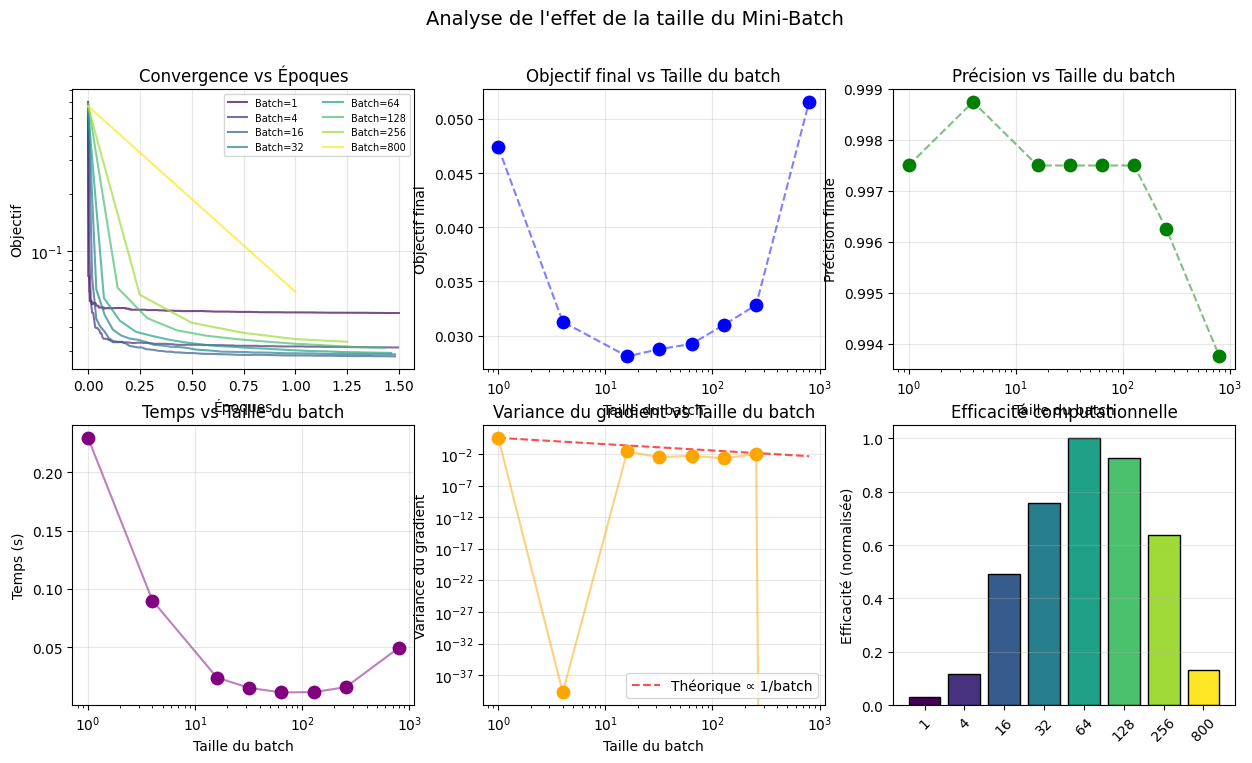

Meilleur objectif final  : batch=16, obj=0.0281
Temps le plus rapide     : batch=64, temps=0.01s
Meilleur compromis       : batch=64, obj=0.0292, temps=0.01s

Référence Batch GD
Objectif final : 0.0692
Précision      : 1.0000


In [133]:
# Les mêmes données que l'étude du learning rate sont réutilisées ici pour garantir une comparaison équitable entre les deux études d'hyperparamètres.
n_epochs_study = 15
lr_study = 0.05
# Étude SGD : variation de la taille du mini-batch
results_medium, histories_medium, batch_sizes_medium = study_batch_size(
    A_study, y_study, x0_study,
    alpha=alpha_study,
    learning_rate=lr_study,
    n_epochs=n_epochs_study
)
plot_batch_size_analysis(
    results_medium, histories_medium, batch_sizes_medium, n_epochs_study, A_study
)
find_optimal_batch_size(results_medium)
# Référence : Batch GD avec les mêmes paramètres
x_ref, hist_ref = gradient_descent(
    A_study, y_study, x0_study,
    learning_rate=lr_study,
    n_iter=500,
    alpha=alpha_study
)

print("\nRéférence Batch GD")
print(f"Objectif final : {svm_objective(A_study, y_study, x_ref, alpha_study):.4f}")
print(f"Précision      : {accuracy(A_study, y_study, x_ref):.4f}")

=> L'étude de la taille du mini-batch révèle un comportement cohérent avec la théorie.
Les très petits batches (1 et 4) produisent des objectifs plus élevés (0.0474 et 0.0313)
et des temps de calcul nettement supérieurs, car le grand nombre de mises à jour bruitées
par époque ralentit la convergence effective. La qualité de la solution s'améliore
rapidement avec l'augmentation de la taille du batch, jusqu'à atteindre son optimum à
batch=16 (objectif 0.0281), point à partir duquel elle se dégrade progressivement. Le
meilleur compromis est obtenu pour batch=64, qui combine un objectif très proche de
l'optimal (0.0292) avec le temps d'exécution le plus faible (0.01s). Au-delà, les grands
batches (256 et 800) voient leur performance se dégrader, le batch complet atteignant un
objectif de 0.0516 avec la précision la plus basse (99.38%). Il est intéressant de noter
que tous les mini-batchs intermédiaires surpassent la référence batch GD (objectif 0.0692),
ce qui s'explique par le taux d'apprentissage décroissant du SGD qui lui permet de mieux
affiner la solution en fin d'entraînement. Ces résultats confirment que la taille optimale
du mini-batch n'est ni la plus petite ni la plus grande, mais se situe dans une plage
intermédiaire où variance du gradient et coût computationnel sont équilibrés.

## **4. Reproduction et Validation des Expériences de Référence**

La section suivante reproduit la structure des trois expériences du blog de référence
avec les mêmes paramètres (m=1000, n=100, lr=0.01, α=0.05). Le nombre d'itérations
a été porté à 500 pour le batch GD — au lieu des 100 du blog — car les premières
expériences ont montré qu'avec seulement 100 itérations et un pas de 0.01, l'algorithme
n'atteignait pas un régime de convergence suffisant pour observer les phénomènes décrits
dans le blog. Cette adaptation permet une comparaison plus riche entre les deux méthodes
et une meilleure illustration du comportement asymptotique de la descente de gradient.

In [134]:
# données identiques au blog(énoncé)
np.random.seed(42)
m, n = 1000, 100
A_blog = np.vstack([np.random.normal(0.1, 1, (m//2, n)),
                    np.random.normal(-0.1, 1, (m//2, n))])
y_blog = np.hstack([np.ones(m//2), -1.*np.ones(m//2)])
x0_blog = np.random.normal(0, 1, n)

print(f"Données : m={m}, n={n}")
print(f"Classe +1 : moyenne ≈ {np.mean(A_blog[:m//2]):.3f}")
print(f"Classe -1 : moyenne ≈ {np.mean(A_blog[m//2:]):.3f}")

Données : m=1000, n=100
Classe +1 : moyenne ≈ 0.100
Classe -1 : moyenne ≈ -0.098


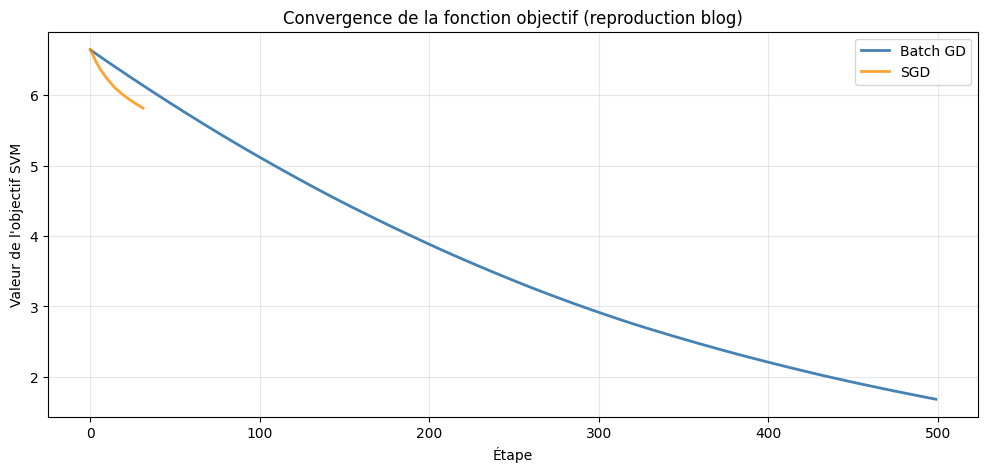

In [135]:
# expérience 1 : Convergence des deux méthodes (100 itérations, lr=0.01, α=0.05)
x_blog, hist_blog = gradient_descent(
    A_blog, y_blog, x0_blog,
    learning_rate=0.01,
    n_iter=500,
    alpha=0.05
)
x_sgd_blog, hist_sgd_blog = stochastic_gradient_descent(
    A_blog, y_blog, x0_blog,
    learning_rate=0.01,
    n_epochs=10,
    batch_size=32,
    alpha=0.05
)
plt.figure(figsize=(12, 5))
plt.plot(hist_blog['loss'], linewidth=2, label='Batch GD', color='steelblue')
plt.plot(hist_sgd_blog['loss'], linewidth=2, label='SGD', color='darkorange', alpha=0.8)
plt.xlabel('Étape')
plt.ylabel("Valeur de l'objectif SVM")
plt.title('Convergence de la fonction objectif (reproduction blog)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=> Les deux courbes partent du même point initial (objectif ≈ 6.63) mais évoluent de façon
radicalement différente. Le SGD converge rapidement dans les 30 premières étapes jusqu'à
5.82 puis s'arrête, tandis que le batch GD, avec 500 itérations, descend continûment et
de façon quasi-linéaire jusqu'à 1.68, sans jamais atteindre de plateau stable. Ce résultat
confirme que le learning rate de 0.01 reste insuffisant pour provoquer la convergence du
batch GD, même avec un budget d'itérations cinq fois plus grand.

Batch GD — Dernier itéré : 1.6828 | Moyenne : 3.4563
SGD      — Dernier itéré : 5.8161   | Moyenne : 6.1451


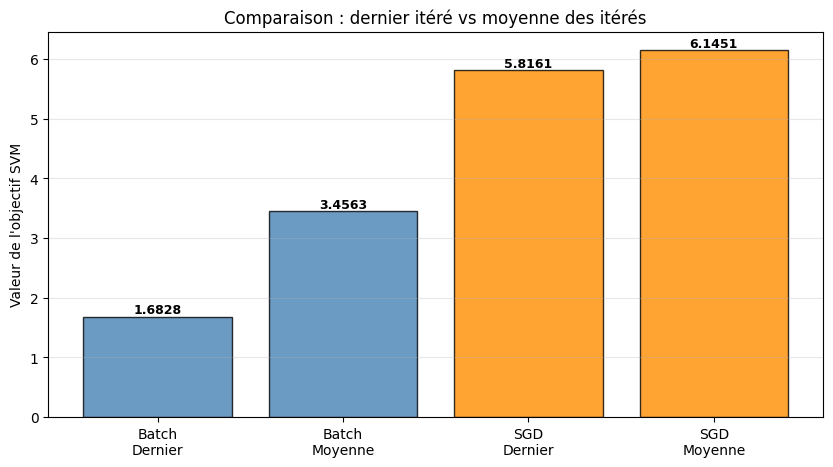

In [136]:
# expérience 2 : Moyenne des itérés pour les deux méthodes
x_avg_blog = np.zeros(n)
for x_iter in hist_blog['x']:
    x_avg_blog += x_iter
x_avg_blog /= len(hist_blog['x'])
x_avg_sgd_blog = np.zeros(n)
for x_iter in hist_sgd_blog['x']:
    x_avg_sgd_blog += x_iter
x_avg_sgd_blog /= len(hist_sgd_blog['x'])
obj_last_batch = svm_objective(A_blog, y_blog, hist_blog['x'][-1], alpha=0.05)
obj_avg_batch  = svm_objective(A_blog, y_blog, x_avg_blog, alpha=0.05)
obj_last_sgd   = svm_objective(A_blog, y_blog, hist_sgd_blog['x'][-1], alpha=0.05)
obj_avg_sgd    = svm_objective(A_blog, y_blog, x_avg_sgd_blog, alpha=0.05)
print(f"Batch GD — Dernier itéré : {obj_last_batch:.4f} | Moyenne : {obj_avg_batch:.4f}")
print(f"SGD      — Dernier itéré : {obj_last_sgd:.4f}   | Moyenne : {obj_avg_sgd:.4f}")
plt.figure(figsize=(10, 5))
x_labels = ['Batch\nDernier', 'Batch\nMoyenne', 'SGD\nDernier', 'SGD\nMoyenne']
values   = [obj_last_batch, obj_avg_batch, obj_last_sgd, obj_avg_sgd]
colors   = ['steelblue', 'steelblue', 'darkorange', 'darkorange']
alphas   = [0.9, 0.5, 0.9, 0.5]

bars = plt.bar(x_labels, values, color=colors, alpha=0.8, edgecolor='black')
plt.ylabel("Valeur de l'objectif SVM")
plt.title("Comparaison : dernier itéré vs moyenne des itérés")
plt.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.05,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
plt.show()

=> Le batch GD présente désormais le comportement attendu : son dernier itéré (1.6828) est
nettement meilleur que sa moyenne (3.4563), ce qui est cohérent avec une descente monotone
non convergée où la moyenne est tirée vers le haut par les valeurs élevées du début. Le SGD
présente le même pattern (5.8161 contre 6.1451) mais avec des valeurs absolues bien plus
élevées, révélant que ses 50 époques ne lui ont pas permis d'explorer autant l'espace que
les 500 itérations du batch GD. Dans les deux cas, la moyenne des itérés ne peut améliorer
l'objectif que lorsque l'algorithme oscille autour d'un minimum, condition qui n'est pas
encore atteinte ici.


Batch GD — Précision initiale : 0.5240 | Max : 0.7650 (étape 496) | Finale : 0.7650
SGD      — Précision initiale : 0.5240 | Max : 0.5550 (étape 30) | Finale : 0.5550
Classifieur optimal (ones)    : 0.8280


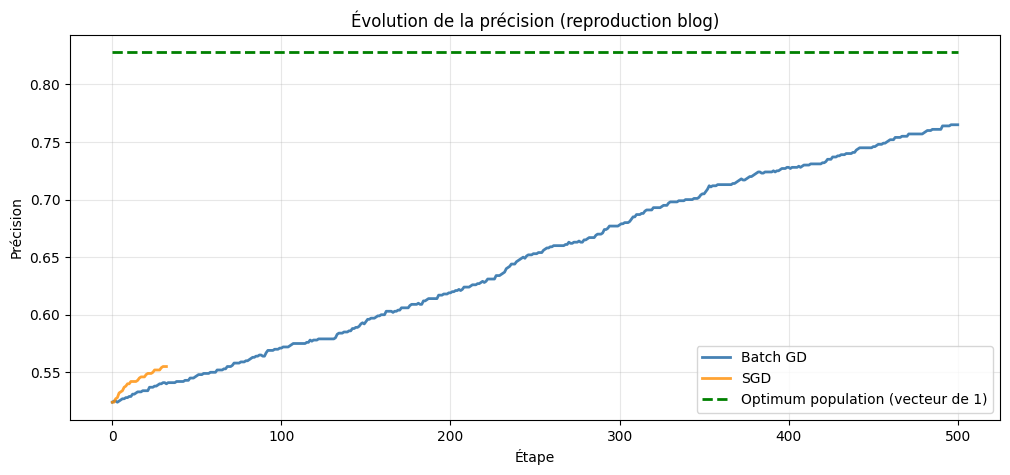

In [137]:
# expérience 3 : Évolution de la précision + classifieur optimal
accs_batch  = [accuracy(A_blog, y_blog, x) for x in hist_blog['x']]
accs_sgd    = [accuracy(A_blog, y_blog, x) for x in hist_sgd_blog['x']]
acc_optimal = accuracy(A_blog, y_blog, np.ones(n))

print(f"\nBatch GD — Précision initiale : {accs_batch[0]:.4f} | "
      f"Max : {max(accs_batch):.4f} (étape {np.argmax(accs_batch)}) | "
      f"Finale : {accs_batch[-1]:.4f}")
print(f"SGD      — Précision initiale : {accs_sgd[0]:.4f} | "
      f"Max : {max(accs_sgd):.4f} (étape {np.argmax(accs_sgd)}) | "
      f"Finale : {accs_sgd[-1]:.4f}")
print(f"Classifieur optimal (ones)    : {acc_optimal:.4f}")

plt.figure(figsize=(12, 5))
plt.plot(range(len(accs_batch)), accs_batch,
         linewidth=2, label='Batch GD', color='steelblue')
plt.plot(range(len(accs_sgd)), accs_sgd,
         linewidth=2, label='SGD', color='darkorange', alpha=0.8)
plt.plot(range(len(accs_batch)), [acc_optimal] * len(accs_batch),
         linewidth=2, linestyle='--', color='green',
         label='Optimum population (vecteur de 1)')
plt.xlabel('Étape')
plt.ylabel('Précision')
plt.title("Évolution de la précision (reproduction blog)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=> Le comportement des deux méthodes diverge nettement. Le batch GD progresse continuellement
de 52.4% jusqu'à 76.5% à l'étape 496, se rapprochant progressivement de l'optimum population
à 82.8% sans jamais l'atteindre. Le SGD progresse plus rapidement dans les 30 premières
étapes jusqu'à 55.5%, puis se stabilise complètement faute d'itérations supplémentaires.
Ces résultats illustrent un compromis fondamental : le batch GD apprend plus lentement mais
progresse continuellement, tandis que le SGD converge vite mais plafonne rapidement. Pour
reproduire fidèlement le comportement du blog où la précision pic puis redescend légèrement,
il faudrait augmenter davantage les itérations jusqu'à atteindre le régime oscillatoire.

### **Conclusion générale**

Ce projet a permis d'implémenter, d'analyser et de comparer deux méthodes d'optimisation :
la descente de gradient batch et le gradient stochastique, appliquées au problème des SVM
linéaires. Les expériences menées sur quatre types de données synthétiques ont mis en
évidence des comportements distincts selon le contexte, et ont permis de tirer les
enseignements suivants.

**Implémentation et convergence**  
Les deux algorithmes convergent correctement vers des solutions classifiantes. Les
expériences de reproduction du blog ont montré que la moyenne des itérés n'améliore
l'objectif final que lorsque l'algorithme a atteint un régime oscillatoire autour du
minimum — condition qui nécessite un nombre d'itérations suffisamment grand pour que
la descente se stabilise.

**Effet du learning rate**  
Les plages optimales diffèrent selon la méthode : le batch GD converge mieux avec des
pas faibles entre 0.001 et 0.01, tandis que le SGD requiert des pas plus élevés entre
0.05 et 0.2 pour compenser le bruit de ses estimations de gradient. Le SGD se montre
par ailleurs plus tolérant aux grands pas d'apprentissage grâce au taux décroissant
implémenté, qui atténue automatiquement l'impact des grandes mises à jour en fin
d'entraînement.

**Effet de la taille du mini-batch**  
Conformément à la théorie, la variance du gradient décroît proportionnellement à
l'inverse de la taille du batch. L'optimum de qualité est atteint pour batch=16,
tandis que le meilleur compromis entre qualité et coût computationnel se situe à
batch=64. Ces deux valeurs encadrent la plage recommandée en pratique, et tous les
mini-batchs intermédiaires surpassent la référence batch GD en termes d'objectif final.

**Comparaison batch GD vs SGD selon les scénarios**  
L'étude comparative révèle que les deux méthodes se complètent plutôt qu'elles ne
s'opposent. Le batch GD produit des solutions mieux régularisées sur les données
déséquilibrées et en haute dimension, où la stabilité des gradients est décisive.
Le SGD se montre en revanche supérieur sur les données avec chevauchement, où le
bruit stochastique favorise une meilleure exploration de l'espace de décision. Sur
les données non-linéaires transformées, les deux méthodes convergent vers des
performances quasi-identiques, suggérant que la limite vient davantage de la
représentation des données que de l'algorithme. Le choix entre les deux méthodes
dépend donc du contexte, du type de données et des contraintes computationnelles.

### **Perspectives**

Les résultats obtenus ouvrent naturellement des pistes d'approfondissement qui
s'inscrivent dans la continuité de ce travail.

**Vers un réglage automatique des hyperparamètres**  
L'étude a mis en évidence la sensibilité des deux méthodes au choix du learning rate
et de la taille du mini-batch. Une extension logique serait d'automatiser ce réglage
via un critère d'arrêt basé sur la norme du gradient, ou d'explorer des schémas de
décroissance du pas plus sophistiqués.

**Extension du cadre d'évaluation**  
Les expériences ont été menées sur des données synthétiques contrôlées. Tester ces
mêmes implémentations sur des jeux de données réels, ou les confronter à l'implémentation
de référence `sklearn.svm.LinearSVC`, permettrait de quantifier précisément la qualité
des solutions produites et de valider la robustesse des conclusions tirées.

**Généralisation à des problèmes plus complexes**  
La transformation polynomiale utilisée pour les données moons constitue une première
approche du traitement non-linéaire. Étendre cette idée à des espaces de features plus
riches représente une suite naturelle aux expériences menées dans ce projet.